## Clustering

We test clustering with the following columns:

- audio features, compressed with PCA; 
- audio and lexical features, compressed with PCA;
- audio and lexical features, compressed with UMAP, with several choices for the number of dimensions;
- audio and lexical features, compressed with T-SNE, with several choices for the number of dimensions.

The best value of $k$ (with best silhouette) is small, so we can find it with brute force (trying all small values of $k$). We compare the best value of $k$ with the one obtained using the elbow method.

The results are commented in much more detail in the report.

In [2]:
from imports import *


artists = pd.read_parquet("tmp/p01_artists.parquet")
tracks = pd.read_parquet("tmp/tracks_with_embeddings.parquet")

X_tsne2 = pd.read_parquet("tmp/X_tsne2.parquet")
X_tsne3 = pd.read_parquet("tmp/X_tsne3.parquet")

X_umap3 = pd.read_parquet("tmp/X_umap3.parquet")
X_umap5 = pd.read_parquet("tmp/X_umap5.parquet")
X_umap8 = pd.read_parquet("tmp/X_umap8.parquet")

pca_audio_cols = pickle.load(open("tmp/pca_audio_cols.pkl", "rb"))
pca_clust_cols = pickle.load(open("tmp/pca_clust_cols.pkl", "rb"))
emb_cols = pickle.load(open("tmp/emb_cols.pkl", "rb"))

FileNotFoundError: [Errno 2] No such file or directory: 'tmp/emb_cols.pkl'

In [ ]:
def kmeans_test(X, min_k = 2, max_k = 8, n_init = 15, verbose = False):

    sse_list = list()
    sscores = list()
    labels = list()
    
    for k in range(min_k, max_k + 1):
        kmeans = KMeans(n_clusters=k, n_init=n_init, max_iter=100)
        labels.append(kmeans.fit_predict(X))
        
        sse = kmeans.inertia_
        sse_list.append(sse)

        sscore = metrics.silhouette_score(X, labels[k-min_k])
        sscores.append(sscore)
        print(f"k = {k}, silhouette = {sscore:.4f}, sse = {sse:.4f}")
        print(np.unique(kmeans.labels_, return_counts=True))


        if verbose:
            centroids = pd.DataFrame(kmeans.cluster_centers_, columns=[f"c_{i+1}" for i in range(X.shape[1])])
            centroids.index = [f"cluster_{i}" for i in range(kmeans.n_clusters)]
            display(centroids)
        
            plt.figure(figsize=(10,6))
            sns.heatmap(centroids, annot=False, cmap="viridis")
            plt.title(f"Cluster centroids across {X.shape[1]} features")
            plt.show()


    _, elbow_k = find_elbow_point(sse_list)
    elbow_k += min_k
    minsscore_k = min_k + sscores.index(max(sscores))
    print(f"best k based on elbow method: {elbow_k}")
    print(f"best k based on min Silhouette score: {minsscore_k}")


    sse_star = sse_list[elbow_k - min_k] 

    plt.plot(range(min_k, len(sse_list) + min_k), sse_list)
    plt.ylabel('SSE', fontsize=18)
    plt.xlabel('K', fontsize=18)
    plt.tick_params(axis='both', which='major', labelsize=13)
    
    # Vertical line ending at the point
    plt.vlines(x=elbow_k, ymin=0, ymax=sse_star, colors='red', linestyles='dashed')
    
    # Horizontal line ending at the point
    plt.hlines(y=sse_star, xmin=0, xmax=elbow_k, colors='red', linestyles='dashed')
    
    # Highlight the point
    plt.scatter(elbow_k, sse_star, color='red', s=50, zorder=5)
    
    plt.show()
    

    return labels, elbow_k, minsscore_k
    

k = 2, silhouette = 0.2259, sse = 63937.0627
(array([0, 1], dtype=int32), array([5726, 4228]))
k = 3, silhouette = 0.1639, sse = 56478.5457
(array([0, 1, 2], dtype=int32), array([3851, 3399, 2704]))
k = 4, silhouette = 0.1463, sse = 51235.8805
(array([0, 1, 2, 3], dtype=int32), array([2249, 2937, 2578, 2190]))
k = 5, silhouette = 0.1509, sse = 47130.4861
(array([0, 1, 2, 3, 4], dtype=int32), array([2149, 2634, 1512, 1807, 1852]))
k = 6, silhouette = 0.1485, sse = 44265.8894
(array([0, 1, 2, 3, 4, 5], dtype=int32), array([1564, 1603, 1857, 1517, 1470, 1943]))
k = 7, silhouette = 0.1507, sse = 41731.3735
(array([0, 1, 2, 3, 4, 5, 6], dtype=int32), array([1289, 1730,  988, 1339, 1537, 1868, 1203]))
k = 8, silhouette = 0.1389, sse = 39873.3660
(array([0, 1, 2, 3, 4, 5, 6, 7], dtype=int32), array([1384, 1012, 1045,  819, 1434, 1318, 1293, 1649]))
k = 9, silhouette = 0.1375, sse = 38361.6014
(array([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=int32), array([ 875, 1305, 1264, 1567,  905,  880,  767, 12

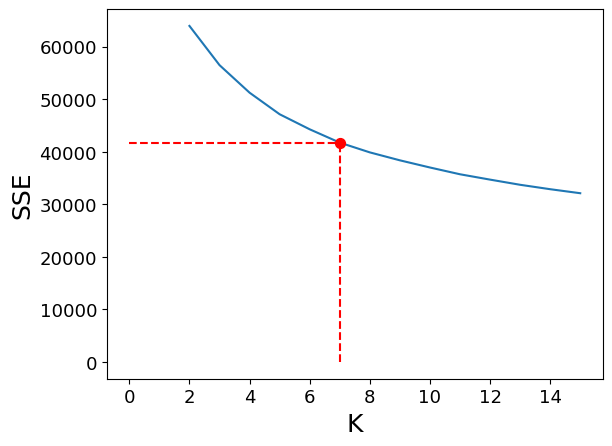

([array([1, 1, 1, ..., 0, 0, 0], shape=(9954,), dtype=int32),
  array([1, 1, 1, ..., 0, 0, 2], shape=(9954,), dtype=int32),
  array([3, 3, 3, ..., 2, 2, 0], shape=(9954,), dtype=int32),
  array([2, 2, 2, ..., 0, 0, 4], shape=(9954,), dtype=int32),
  array([4, 4, 4, ..., 2, 2, 0], shape=(9954,), dtype=int32),
  array([3, 3, 0, ..., 1, 1, 2], shape=(9954,), dtype=int32),
  array([3, 3, 6, ..., 5, 7, 2], shape=(9954,), dtype=int32),
  array([5, 5, 2, ..., 8, 3, 6], shape=(9954,), dtype=int32),
  array([0, 0, 4, ..., 8, 8, 9], shape=(9954,), dtype=int32),
  array([5, 5, 4, ..., 6, 2, 9], shape=(9954,), dtype=int32),
  array([6, 6, 8, ..., 7, 5, 3], shape=(9954,), dtype=int32),
  array([ 4,  4,  0, ...,  5,  8, 12], shape=(9954,), dtype=int32),
  array([ 0,  0, 11, ...,  5,  4,  1], shape=(9954,), dtype=int32),
  array([ 3,  3,  8, ...,  6,  9, 12], shape=(9954,), dtype=int32)],
 7,
 2)

In [ ]:
kmeans_test(tracks[pca_audio_cols])

k = 2, silhouette = 0.1565, sse = 109461.3392
(array([0, 1], dtype=int32), array([5454, 4500]))
k = 3, silhouette = 0.1258, sse = 99568.2173
(array([0, 1, 2], dtype=int32), array([3262, 3309, 3383]))
k = 4, silhouette = 0.0990, sse = 93972.0607
(array([0, 1, 2, 3], dtype=int32), array([2697, 2112, 2709, 2436]))
k = 5, silhouette = 0.1022, sse = 89735.6137
(array([0, 1, 2, 3, 4], dtype=int32), array([2246, 1519, 2102, 2370, 1717]))
k = 6, silhouette = 0.0990, sse = 86101.8127
(array([0, 1, 2, 3, 4, 5], dtype=int32), array([1406, 2305, 1417, 1482, 1979, 1365]))
k = 7, silhouette = 0.1013, sse = 82788.6644
(array([0, 1, 2, 3, 4, 5, 6], dtype=int32), array([1358, 1383, 1315, 1942, 1411, 2239,  306]))
k = 8, silhouette = 0.0958, sse = 80361.0056
(array([0, 1, 2, 3, 4, 5, 6, 7], dtype=int32), array([1254, 1736,  282, 1292, 1296, 1315, 1622, 1157]))
k = 9, silhouette = 0.0905, sse = 78317.5163
(array([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=int32), array([ 906, 1191, 1025, 1508, 1276, 1083,  271, 1

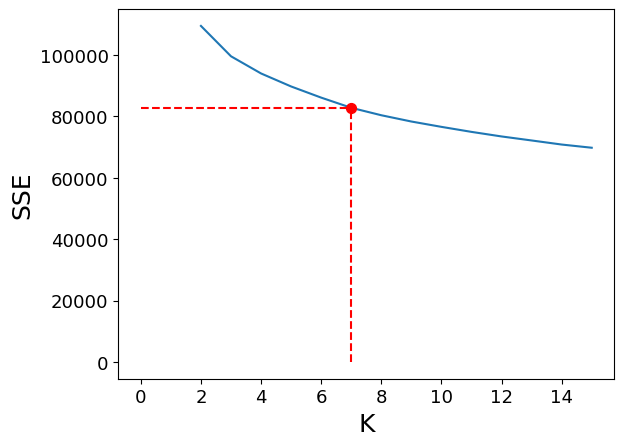

([array([1, 1, 1, ..., 0, 0, 0], shape=(9954,), dtype=int32),
  array([1, 1, 1, ..., 0, 0, 2], shape=(9954,), dtype=int32),
  array([1, 1, 1, ..., 2, 0, 3], shape=(9954,), dtype=int32),
  array([4, 4, 4, ..., 0, 3, 1], shape=(9954,), dtype=int32),
  array([0, 0, 3, ..., 4, 4, 5], shape=(9954,), dtype=int32),
  array([0, 0, 4, ..., 3, 3, 2], shape=(9954,), dtype=int32),
  array([5, 5, 3, ..., 6, 6, 7], shape=(9954,), dtype=int32),
  array([1, 7, 1, ..., 3, 3, 0], shape=(9954,), dtype=int32),
  array([0, 2, 0, ..., 1, 1, 5], shape=(9954,), dtype=int32),
  array([ 3,  3,  1, ..., 10,  9,  7], shape=(9954,), dtype=int32),
  array([7, 4, 7, ..., 8, 2, 5], shape=(9954,), dtype=int32),
  array([11,  3, 11, ..., 12, 12,  9], shape=(9954,), dtype=int32),
  array([11, 12, 11, ..., 13,  7,  4], shape=(9954,), dtype=int32),
  array([ 4,  2,  4, ..., 11,  8,  5], shape=(9954,), dtype=int32)],
 7,
 2)

In [ ]:
kmeans_test(tracks[pca_clust_cols])

k = 2, silhouette = 0.3117, sse = 29693.9746
(array([0, 1], dtype=int32), array([4941, 5013]))
k = 3, silhouette = 0.3034, sse = 22485.1758
(array([0, 1, 2], dtype=int32), array([3392, 3428, 3134]))
k = 4, silhouette = 0.3024, sse = 18202.6602
(array([0, 1, 2, 3], dtype=int32), array([2487, 2477, 2931, 2059]))
k = 5, silhouette = 0.2995, sse = 15424.8857
(array([0, 1, 2, 3, 4], dtype=int32), array([2269, 2340, 1845, 1866, 1634]))
k = 6, silhouette = 0.2922, sse = 13626.5332
(array([0, 1, 2, 3, 4, 5], dtype=int32), array([1554, 1416, 2129, 1677, 1450, 1728]))
k = 7, silhouette = 0.2912, sse = 12123.9004
(array([0, 1, 2, 3, 4, 5, 6], dtype=int32), array([1390, 1878, 1510, 1369, 1138, 1412, 1257]))
k = 8, silhouette = 0.2903, sse = 10847.1875
(array([0, 1, 2, 3, 4, 5, 6, 7], dtype=int32), array([1075, 1353, 1646, 1229, 1169, 1271,  992, 1219]))
k = 9, silhouette = 0.2812, sse = 9993.9863
(array([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=int32), array([ 963, 1220, 1163, 1282, 1158, 1166, 1094,  84

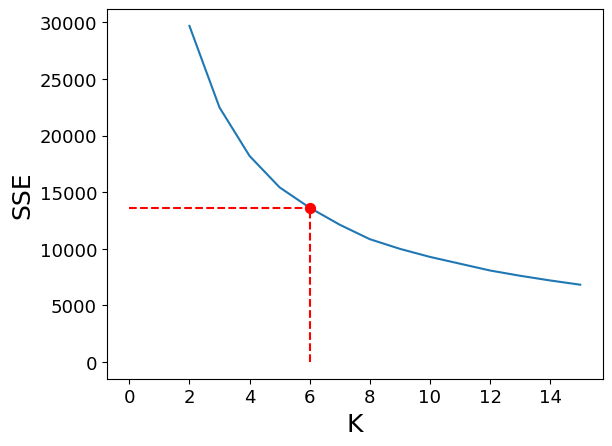

([array([1, 1, 1, ..., 0, 0, 0], shape=(9954,), dtype=int32),
  array([1, 1, 1, ..., 2, 0, 0], shape=(9954,), dtype=int32),
  array([2, 2, 2, ..., 1, 3, 3], shape=(9954,), dtype=int32),
  array([1, 1, 1, ..., 0, 0, 2], shape=(9954,), dtype=int32),
  array([2, 2, 2, ..., 1, 1, 5], shape=(9954,), dtype=int32),
  array([1, 1, 1, ..., 0, 0, 6], shape=(9954,), dtype=int32),
  array([2, 2, 0, ..., 7, 7, 3], shape=(9954,), dtype=int32),
  array([2, 2, 8, ..., 6, 6, 0], shape=(9954,), dtype=int32),
  array([4, 4, 5, ..., 8, 8, 9], shape=(9954,), dtype=int32),
  array([5, 5, 6, ..., 3, 1, 8], shape=(9954,), dtype=int32),
  array([ 1,  1,  3, ...,  2, 10,  4], shape=(9954,), dtype=int32),
  array([ 5,  5, 11, ...,  6,  3,  9], shape=(9954,), dtype=int32),
  array([ 3,  7,  3, ..., 12,  2,  0], shape=(9954,), dtype=int32),
  array([ 2, 13,  2, ...,  5,  5, 12], shape=(9954,), dtype=int32)],
 6,
 2)

In [ ]:
kmeans_test(X_umap3)

k = 2, silhouette = 0.2983, sse = 24894.6289
(array([0, 1], dtype=int32), array([5372, 4582]))
k = 3, silhouette = 0.2689, sse = 19766.5918
(array([0, 1, 2], dtype=int32), array([3526, 3301, 3127]))
k = 4, silhouette = 0.2459, sse = 17385.4531
(array([0, 1, 2, 3], dtype=int32), array([2108, 2795, 2617, 2434]))
k = 5, silhouette = 0.2507, sse = 15240.0928
(array([0, 1, 2, 3, 4], dtype=int32), array([1472, 2162, 2345, 2231, 1744]))
k = 6, silhouette = 0.2428, sse = 13730.2275
(array([0, 1, 2, 3, 4, 5], dtype=int32), array([1555, 1444, 1733, 1405, 1803, 2014]))
k = 7, silhouette = 0.2477, sse = 12578.1328
(array([0, 1, 2, 3, 4, 5, 6], dtype=int32), array([1769, 1411, 1113, 1564, 1367, 1195, 1535]))
k = 8, silhouette = 0.2458, sse = 11677.1426
(array([0, 1, 2, 3, 4, 5, 6, 7], dtype=int32), array([1088, 1064, 1628, 1390, 1296,  893, 1423, 1172]))
k = 9, silhouette = 0.2357, sse = 10958.8262
(array([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=int32), array([ 887, 1041,  983, 1362, 1269, 1068, 1233,  8

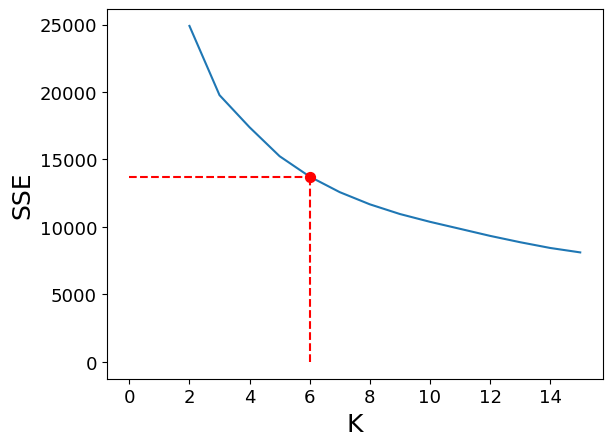

([array([1, 1, 1, ..., 0, 0, 0], shape=(9954,), dtype=int32),
  array([0, 0, 0, ..., 2, 1, 1], shape=(9954,), dtype=int32),
  array([3, 3, 3, ..., 2, 2, 0], shape=(9954,), dtype=int32),
  array([3, 3, 3, ..., 1, 2, 4], shape=(9954,), dtype=int32),
  array([5, 5, 5, ..., 0, 0, 2], shape=(9954,), dtype=int32),
  array([0, 0, 0, ..., 6, 6, 2], shape=(9954,), dtype=int32),
  array([2, 2, 0, ..., 3, 3, 5], shape=(9954,), dtype=int32),
  array([8, 8, 5, ..., 6, 6, 7], shape=(9954,), dtype=int32),
  array([5, 5, 5, ..., 3, 3, 2], shape=(9954,), dtype=int32),
  array([ 2,  8,  2, ...,  1,  1, 10], shape=(9954,), dtype=int32),
  array([ 2,  2,  9, ..., 11, 11,  1], shape=(9954,), dtype=int32),
  array([ 4,  4,  9, ..., 10, 10,  8], shape=(9954,), dtype=int32),
  array([11, 11,  1, ...,  8,  8,  7], shape=(9954,), dtype=int32),
  array([ 9,  6,  9, ..., 12, 12,  4], shape=(9954,), dtype=int32)],
 6,
 2)

In [ ]:
kmeans_test(X_umap5)

k = 2, silhouette = 0.2993, sse = 24535.0469
(array([0, 1], dtype=int32), array([5357, 4597]))
k = 3, silhouette = 0.2667, sse = 19541.7539
(array([0, 1, 2], dtype=int32), array([3120, 3294, 3540]))
k = 4, silhouette = 0.2453, sse = 17161.8184
(array([0, 1, 2, 3], dtype=int32), array([2340, 2797, 2647, 2170]))
k = 5, silhouette = 0.2483, sse = 15105.7383
(array([0, 1, 2, 3, 4], dtype=int32), array([1458, 2095, 2121, 1830, 2450]))
k = 6, silhouette = 0.2401, sse = 13616.4971
(array([0, 1, 2, 3, 4, 5], dtype=int32), array([1800, 1972, 1439, 1775, 1380, 1588]))
k = 7, silhouette = 0.2442, sse = 12518.3838
(array([0, 1, 2, 3, 4, 5, 6], dtype=int32), array([1376, 1181, 1554, 1768, 1147, 1368, 1560]))
k = 8, silhouette = 0.2421, sse = 11625.0742
(array([0, 1, 2, 3, 4, 5, 6, 7], dtype=int32), array([1120, 1070, 1405, 1620, 1074, 1296, 1391,  978]))
k = 9, silhouette = 0.2332, sse = 10917.8594
(array([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=int32), array([ 839, 1281, 1235, 1252, 1055, 1072,  971,  9

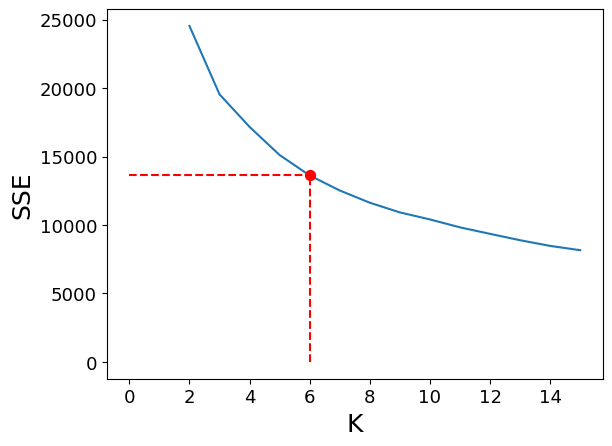

([array([1, 1, 1, ..., 0, 0, 0], shape=(9954,), dtype=int32),
  array([2, 2, 2, ..., 0, 1, 1], shape=(9954,), dtype=int32),
  array([0, 0, 0, ..., 2, 2, 3], shape=(9954,), dtype=int32),
  array([1, 1, 1, ..., 4, 4, 3], shape=(9954,), dtype=int32),
  array([1, 1, 1, ..., 5, 5, 3], shape=(9954,), dtype=int32),
  array([3, 3, 3, ..., 2, 2, 4], shape=(9954,), dtype=int32),
  array([3, 3, 3, ..., 6, 6, 7], shape=(9954,), dtype=int32),
  array([3, 3, 3, ..., 2, 2, 0], shape=(9954,), dtype=int32),
  array([2, 2, 8, ..., 4, 4, 9], shape=(9954,), dtype=int32),
  array([8, 8, 3, ..., 1, 1, 9], shape=(9954,), dtype=int32),
  array([2, 2, 8, ..., 1, 1, 3], shape=(9954,), dtype=int32),
  array([11, 11,  4, ...,  3,  3,  7], shape=(9954,), dtype=int32),
  array([ 2,  2, 13, ..., 11, 11,  4], shape=(9954,), dtype=int32),
  array([14, 14,  4, ..., 11, 11,  8], shape=(9954,), dtype=int32)],
 6,
 2)

In [ ]:
kmeans_test(X_umap8)

## Clustering with full lyrics + BERT

In [ ]:
tracks_ = tracks.dropna(subset=emb_cols, inplace=True)

k = 2, silhouette = 0.0518, sse = 5099.8213
(array([0, 1], dtype=int32), array([5558, 4396]))
k = 3, silhouette = 0.0450, sse = 4936.1001
(array([0, 1, 2], dtype=int32), array([3947, 3733, 2274]))
k = 4, silhouette = 0.0385, sse = 4838.2549
(array([0, 1, 2, 3], dtype=int32), array([2223, 1818, 2978, 2935]))
k = 5, silhouette = 0.0316, sse = 4776.3950
(array([0, 1, 2, 3, 4], dtype=int32), array([1891, 2628, 1566, 2310, 1559]))
k = 6, silhouette = 0.0283, sse = 4723.3970
(array([0, 1, 2, 3, 4, 5], dtype=int32), array([1895, 1490, 1698, 1632, 1454, 1785]))
k = 7, silhouette = 0.0239, sse = 4684.4971
(array([0, 1, 2, 3, 4, 5, 6], dtype=int32), array([1483, 1264, 1335, 1204, 1780, 1290, 1598]))
k = 8, silhouette = 0.0250, sse = 4649.5562
(array([0, 1, 2, 3, 4, 5, 6, 7], dtype=int32), array([1558, 1332, 1644, 1368,  901, 1082,  937, 1132]))
k = 9, silhouette = 0.0193, sse = 4618.0366
(array([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=int32), array([ 909,  987, 1305,  862,  886, 1344, 1299, 1420,  942

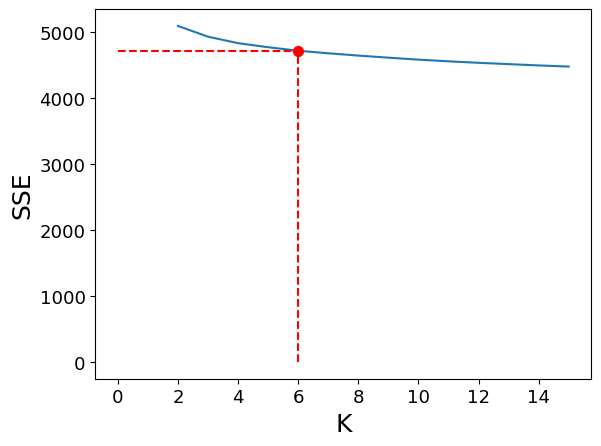

([array([1, 1, 1, ..., 1, 1, 1], shape=(9954,), dtype=int32),
  array([2, 2, 2, ..., 1, 1, 2], shape=(9954,), dtype=int32),
  array([2, 1, 1, ..., 0, 2, 1], shape=(9954,), dtype=int32),
  array([1, 2, 2, ..., 4, 1, 2], shape=(9954,), dtype=int32),
  array([0, 1, 1, ..., 4, 2, 1], shape=(9954,), dtype=int32),
  array([6, 2, 2, ..., 3, 5, 2], shape=(9954,), dtype=int32),
  array([2, 7, 7, ..., 6, 3, 6], shape=(9954,), dtype=int32),
  array([7, 6, 3, ..., 0, 6, 0], shape=(9954,), dtype=int32),
  array([4, 4, 4, ..., 9, 8, 9], shape=(9954,), dtype=int32),
  array([4, 4, 4, ..., 5, 9, 5], shape=(9954,), dtype=int32),
  array([9, 9, 9, ..., 8, 7, 8], shape=(9954,), dtype=int32),
  array([2, 2, 2, ..., 5, 0, 5], shape=(9954,), dtype=int32),
  array([ 0,  0,  0, ...,  8,  3, 12], shape=(9954,), dtype=int32),
  array([ 3,  3,  3, ...,  6,  1, 13], shape=(9954,), dtype=int32)],
 6,
 2)

In [ ]:
kmeans_test(tracks_[emb_cols])

Nothing fancy....

## Best results

k = 3, silhouette = 0.3036, sse = 22485.0762
(array([0, 1, 2], dtype=int32), array([3144, 3377, 3433]))
best k based on elbow method: 2
best k based on min Silohoutte score: 3


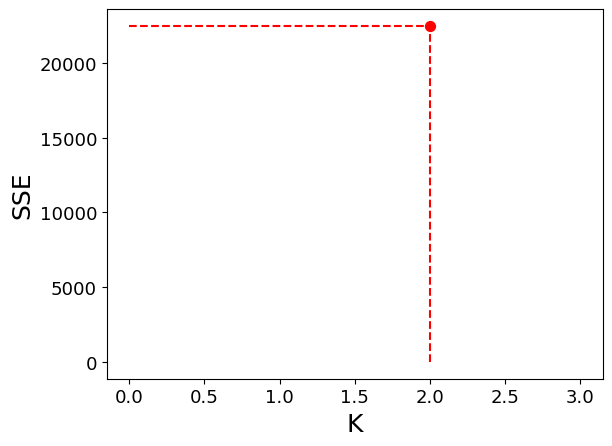

<Axes: xlabel='umap3_1', ylabel='umap3_2'>

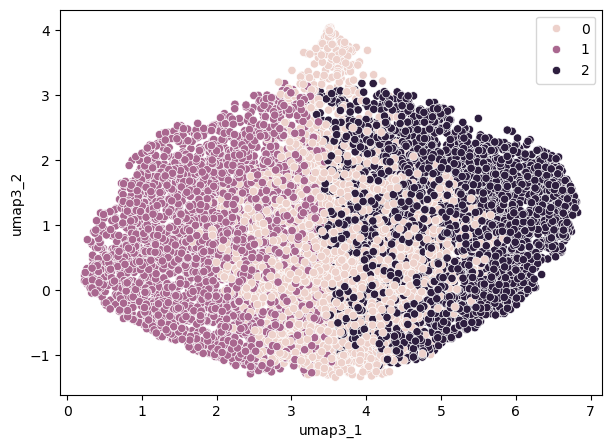

In [ ]:
labels, _, _ = kmeans_test(X_umap3, min_k=3, max_k=3, n_init = 50)
plt.figure(figsize=(7,5))
sns.scatterplot(data=X_umap3, x=X_umap3.columns[0], y=X_umap3.columns[1], hue=labels[0])

k = 6, silhouette = 0.2922, sse = 13626.5137
(array([0, 1, 2, 3, 4, 5], dtype=int32), array([1416, 2129, 1553, 1727, 1450, 1679]))
best k based on elbow method: 5
best k based on min Silohoutte score: 6


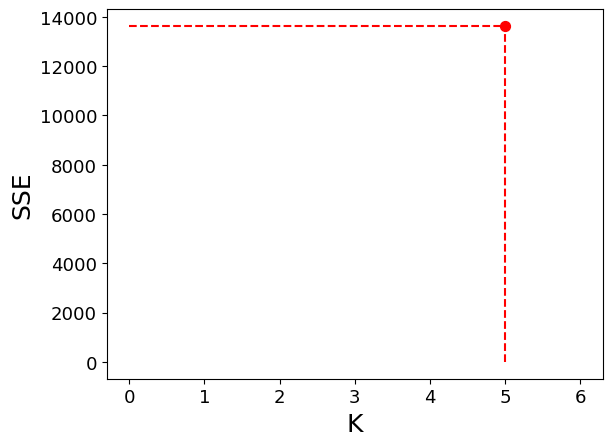

<Axes: xlabel='umap3_1', ylabel='umap3_2'>

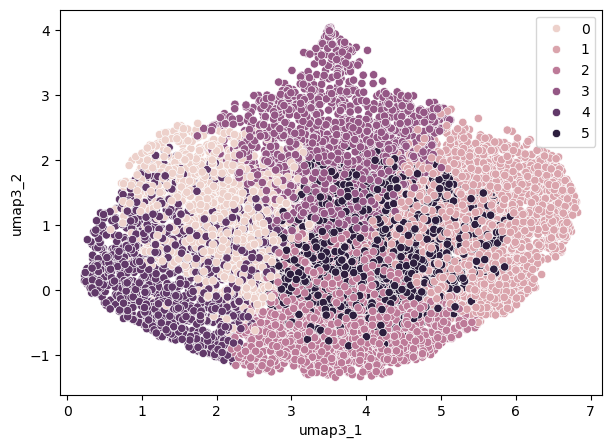

In [ ]:
labels, _, _ = kmeans_test(X_umap3, min_k=6, max_k=6, n_init = 50)
plt.figure(figsize=(7,5))
sns.scatterplot(data=X_umap3, x=X_umap3.columns[0], y=X_umap3.columns[1], hue=labels[0])

k = 7, silhouette = 0.1506, sse = 41731.7217
(array([0, 1, 2, 3, 4, 5, 6], dtype=int32), array([ 965, 1304, 1526, 1857, 1746, 1336, 1220]))
best k based on elbow method: 6
best k based on min Silohoutte score: 7


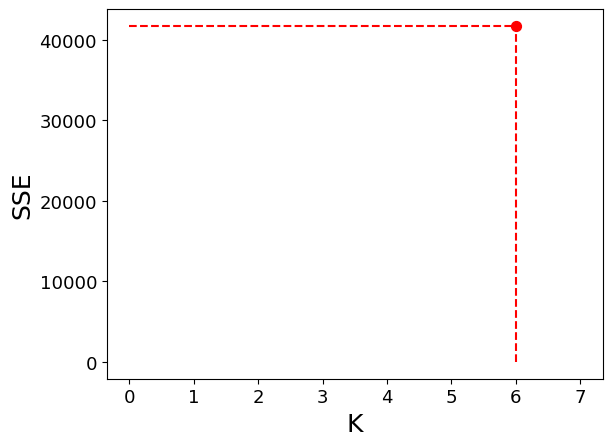

<Axes: xlabel='pc_audio_1', ylabel='pc_audio_2'>

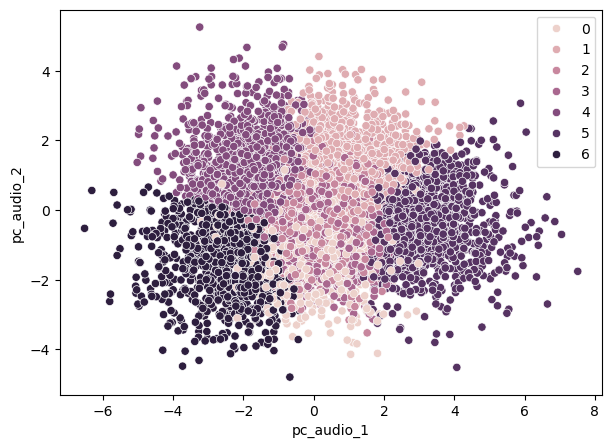

In [ ]:
labels, _, _ = kmeans_test(tracks[pca_audio_cols], min_k=7, max_k=7)
plt.figure(figsize=(7,5))
sns.scatterplot(data=tracks, x=tracks[pca_audio_cols].columns[0], y=tracks[pca_audio_cols].columns[1], hue=labels[0])

k = 4, silhouette = 0.1466, sse = 51236.1841
(array([0, 1, 2, 3], dtype=int32), array([2957, 2585, 2195, 2217]))
best k based on elbow method: 3
best k based on min Silohoutte score: 4


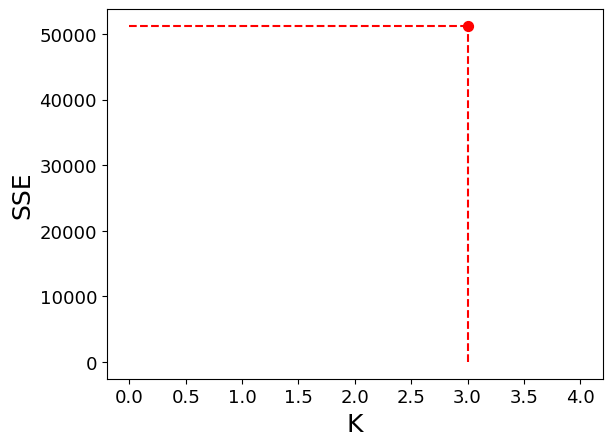

<Axes: xlabel='pc_audio_1', ylabel='pc_audio_2'>

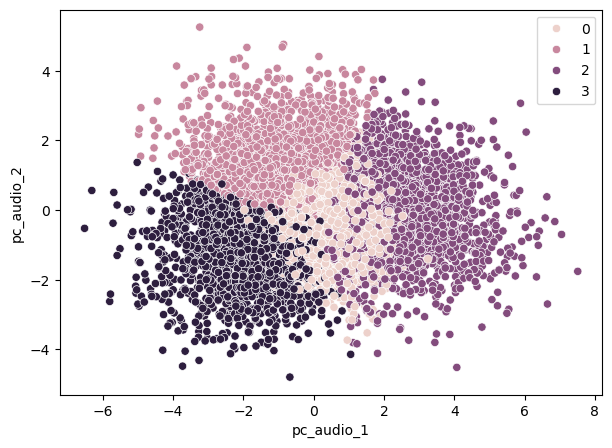

In [ ]:
labels, _, _ = kmeans_test(tracks[pca_audio_cols], min_k=4, max_k=4)
plt.figure(figsize=(7,5))
sns.scatterplot(data=tracks[pca_audio_cols], x=tracks[pca_audio_cols].columns[0], y=tracks[pca_audio_cols].columns[1], hue=labels[0])